In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Display basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


### 1. Dataset Definition and Understanding

#### Dataset Structure
The dataset `/content/data.csv` contains loan application details. Based on the initial info, here are the variable definitions:

*   **Loan_ID**: Unique identifier for the loan.
*   **Gender**: Applicant gender.
*   **Married**: Applicant marital status.
*   **Dependents**: Number of dependents.
*   **Education**: Education level (Graduate/Not Graduate).
*   **Self_Employed**: Employment status.
*   **ApplicantIncome**: Primary income of the applicant.
*   **CoapplicantIncome**: Income of the co-applicant.
*   **LoanAmount**: Total loan amount requested.
*   **Loan_Amount_Term**: Term of the loan in months.
*   **Credit_History**: Credit history meets guidelines (1.0 or 0.0).
*   **Property_Area**: Urban, Semi Urban, or Rural.
*   **Loan_Status**: Target variable (Y/N) indicating if the loan was approved.

#### Target Variables for Credit Risk Modeling

1.  **Probability of Default (PD)**:
    *   **Target**: `Loan_Status` (to be encoded where 'N' represents default/refusal).
    *   **Description**: Predicts the likelihood of an applicant defaulting on the loan.

2.  **Loss Given Default (LGD)**:
    *   **Target**: Not explicitly provided in this file (requires recovery/loss data).
    *   **Description**: The share of an asset that is lost if a borrower defaults.

3.  **Exposure at Default (EAD)**:
    *   **Target**: `LoanAmount` (as a proxy).
    *   **Description**: The total value a bank is exposed to at the time of default.

### 1. Dataset Definition and Understanding

#### Dataset Structure
The dataset `/content/data.csv` contains loan application details. Based on the initial info, here are the variable definitions:

*   **Loan_ID**: Unique identifier for the loan.
*   **Gender**: Applicant gender.
*   **Married**: Applicant marital status.
*   **Dependents**: Number of dependents.
*   **Education**: Education level (Graduate/Not Graduate).
*   **Self_Employed**: Employment status.
*   **ApplicantIncome**: Primary income of the applicant.
*   **CoapplicantIncome**: Income of the co-applicant.
*   **LoanAmount**: Total loan amount requested.
*   **Loan_Amount_Term**: Term of the loan in months.
*   **Credit_History**: Credit history meets guidelines (1.0 or 0.0).
*   **Property_Area**: Urban, Semi Urban, or Rural.
*   **Loan_Status**: Target variable (Y/N) indicating if the loan was approved.

#### Target Variables for Credit Risk Modeling

1.  **Probability of Default (PD)**:
    *   **Target**: `Loan_Status` (to be encoded where 'N' represents default/refusal).
    *   **Description**: Predicts the likelihood of an applicant defaulting on the loan.

2.  **Loss Given Default (LGD)**:
    *   **Target**: Not explicitly provided in this file (requires recovery/loss data).
    *   **Description**: The share of an asset that is lost if a borrower defaults.

3.  **Exposure at Default (EAD)**:
    *   **Target**: `LoanAmount` (as a proxy).
    *   **Description**: The total value a bank is exposed to at the time of default.

### 1. Dataset Definition and Understanding

#### Dataset Structure
The dataset `/content/data.csv` contains loan application details. Based on the initial info, here are the variable definitions:

*   **Loan_ID**: Unique identifier for the loan.
*   **Gender**: Applicant gender.
*   **Married**: Applicant marital status.
*   **Dependents**: Number of dependents.
*   **Education**: Education level (Graduate/Not Graduate).
*   **Self_Employed**: Employment status.
*   **ApplicantIncome**: Primary income of the applicant.
*   **CoapplicantIncome**: Income of the co-applicant.
*   **LoanAmount**: Total loan amount requested.
*   **Loan_Amount_Term**: Term of the loan in months.
*   **Credit_History**: Credit history meets guidelines (1.0 or 0.0).
*   **Property_Area**: Urban, Semi Urban, or Rural.
*   **Loan_Status**: Target variable (Y/N) indicating if the loan was approved.

#### Target Variables for Credit Risk Modeling

1.  **Probability of Default (PD)**:
    *   **Target**: `Loan_Status` (to be encoded where 'N' represents default/refusal).
    *   **Description**: Predicts the likelihood of an applicant defaulting on the loan.

2.  **Loss Given Default (LGD)**:
    *   **Target**: Not explicitly provided in this file (requires recovery/loss data).
    *   **Description**: The share of an asset that is lost if a borrower defaults.

3.  **Exposure at Default (EAD)**:
    *   **Target**: `LoanAmount` (as a proxy).
    *   **Description**: The total value a bank is exposed to at the time of default.

### 2. Exploratory Data Analysis (EDA)

We will now explore the data to identify key risk drivers for:
*   **PD**: Relationship between features (like Credit History) and Loan Status.
*   **EAD**: Distribution of Loan Amount.
*   **LGD**: Limitations due to missing recovery data.

/tmp/ipykernel_9497/1639270149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='viridis')


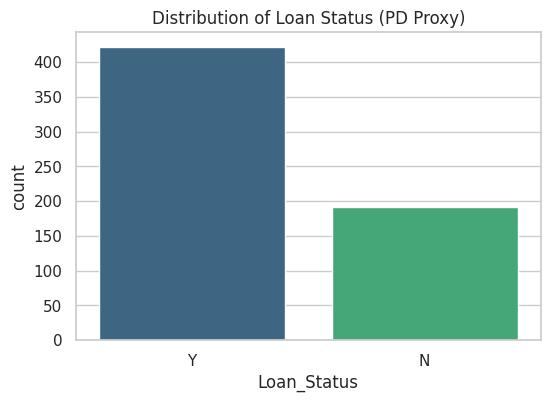

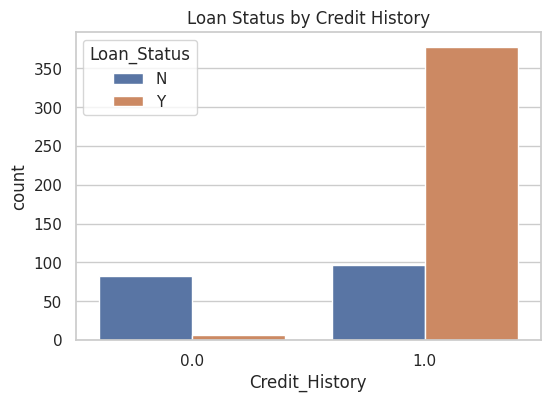

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. PD Analysis: Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='viridis')
plt.title('Distribution of Loan Status (PD Proxy)')
plt.show()

# 2. PD Analysis: Credit History as a Driver
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status')
plt.title('Loan Status by Credit History')
plt.show()

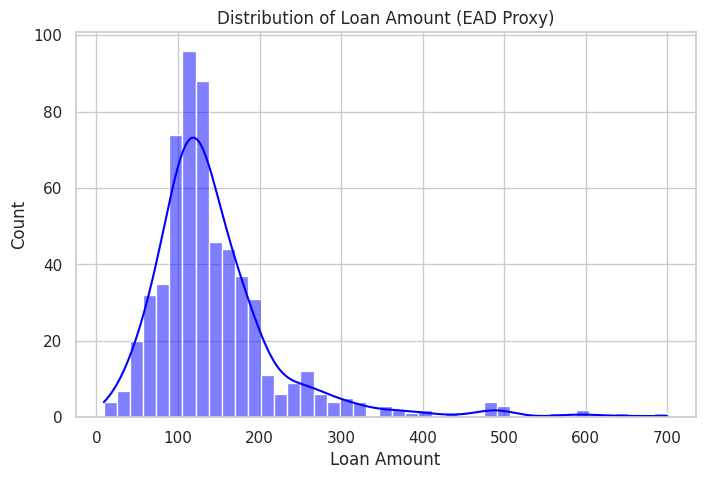

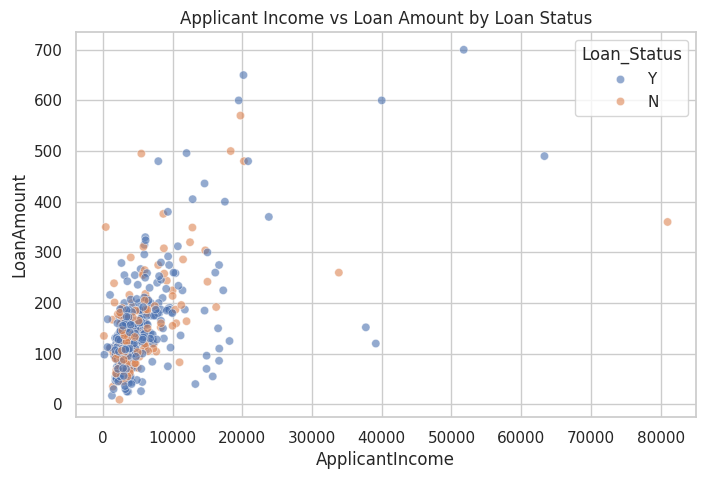

In [ ]:
# 3. EAD Analysis: Exposure Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'].dropna(), kde=True, color='blue')
plt.title('Distribution of Loan Amount (EAD Proxy)')
plt.xlabel('Loan Amount')
plt.show()

# 4. Risk Drivers: Income vs Loan Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', alpha=0.6)
plt.title('Applicant Income vs Loan Amount by Loan Status')
plt.show()

#### Insights from EDA:
*   **Credit History**: Appears to be the strongest predictor for `Loan_Status`.
*   **Exposure**: Most loans are concentrated in the 100-200 range.
*   **LGD Note**: Without recovery data, we cannot empirically model LGD. We will assume a fixed recovery rate or flag this for future data collection.

### 2.1 Correlation Analysis

To identify key risk drivers numerically, we will calculate the correlation matrix. We first need to encode categorical variables like `Loan_Status` and `Credit_History` to see their impact on the outcome.

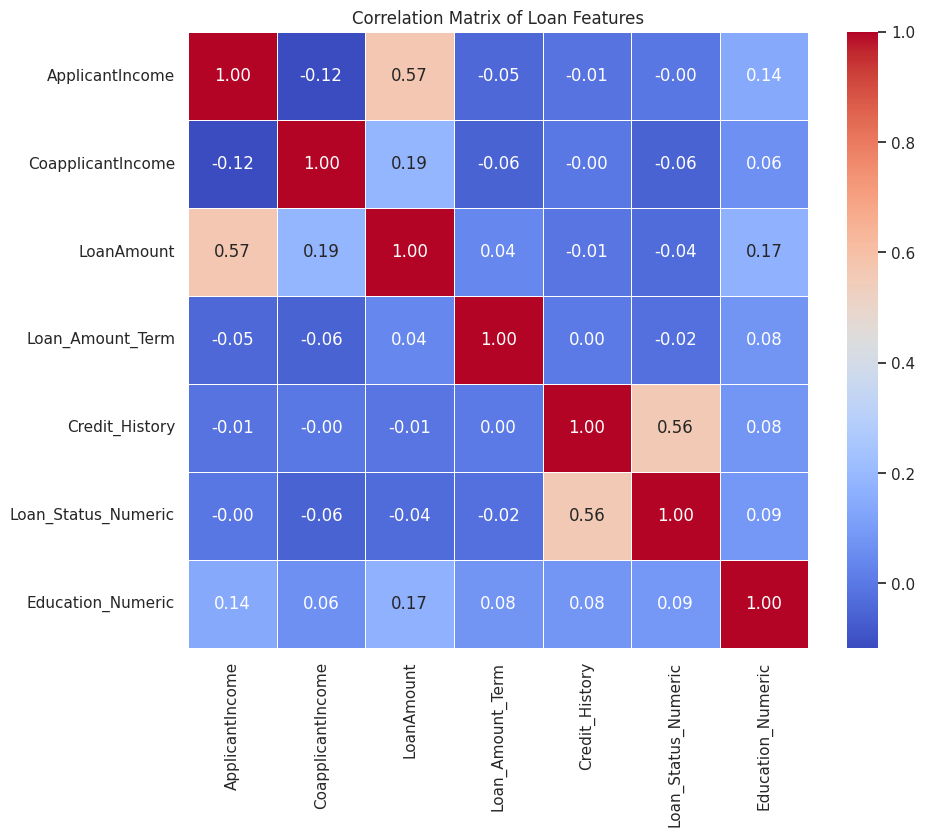

Correlation with Loan Status (Numerical):
Loan_Status_Numeric    1.000000
Credit_History         0.561678
Education_Numeric      0.085884
ApplicantIncome       -0.004710
Loan_Amount_Term      -0.021268
LoanAmount            -0.037318
CoapplicantIncome     -0.059187
Name: Loan_Status_Numeric, dtype: float64


In [ ]:
# Create a copy for correlation analysis
corr_df = df.copy()

# Encode Target and key categorical variables
corr_df['Loan_Status_Numeric'] = corr_df['Loan_Status'].map({'Y': 1, 'N': 0})
corr_df['Education_Numeric'] = corr_df['Education'].map({'Graduate': 1, 'Not Graduate': 0})

# Select numerical columns for correlation
numerical_cols = corr_df.select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = corr_df[numerical_cols].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Loan Features')
plt.show()

# Display specific correlations with Loan_Status
print("Correlation with Loan Status (Numerical):")
print(correlation_matrix['Loan_Status_Numeric'].sort_values(ascending=False))

### 2.2 Data Quality Check: Missing Values and Outliers

Before preprocessing, we need to quantify the missing data and identify extreme values (outliers) that might skew our risk models.

Missing Values per Column:


,0
Gender,13
Married,3
Dependents,15
Self_Employed,32
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


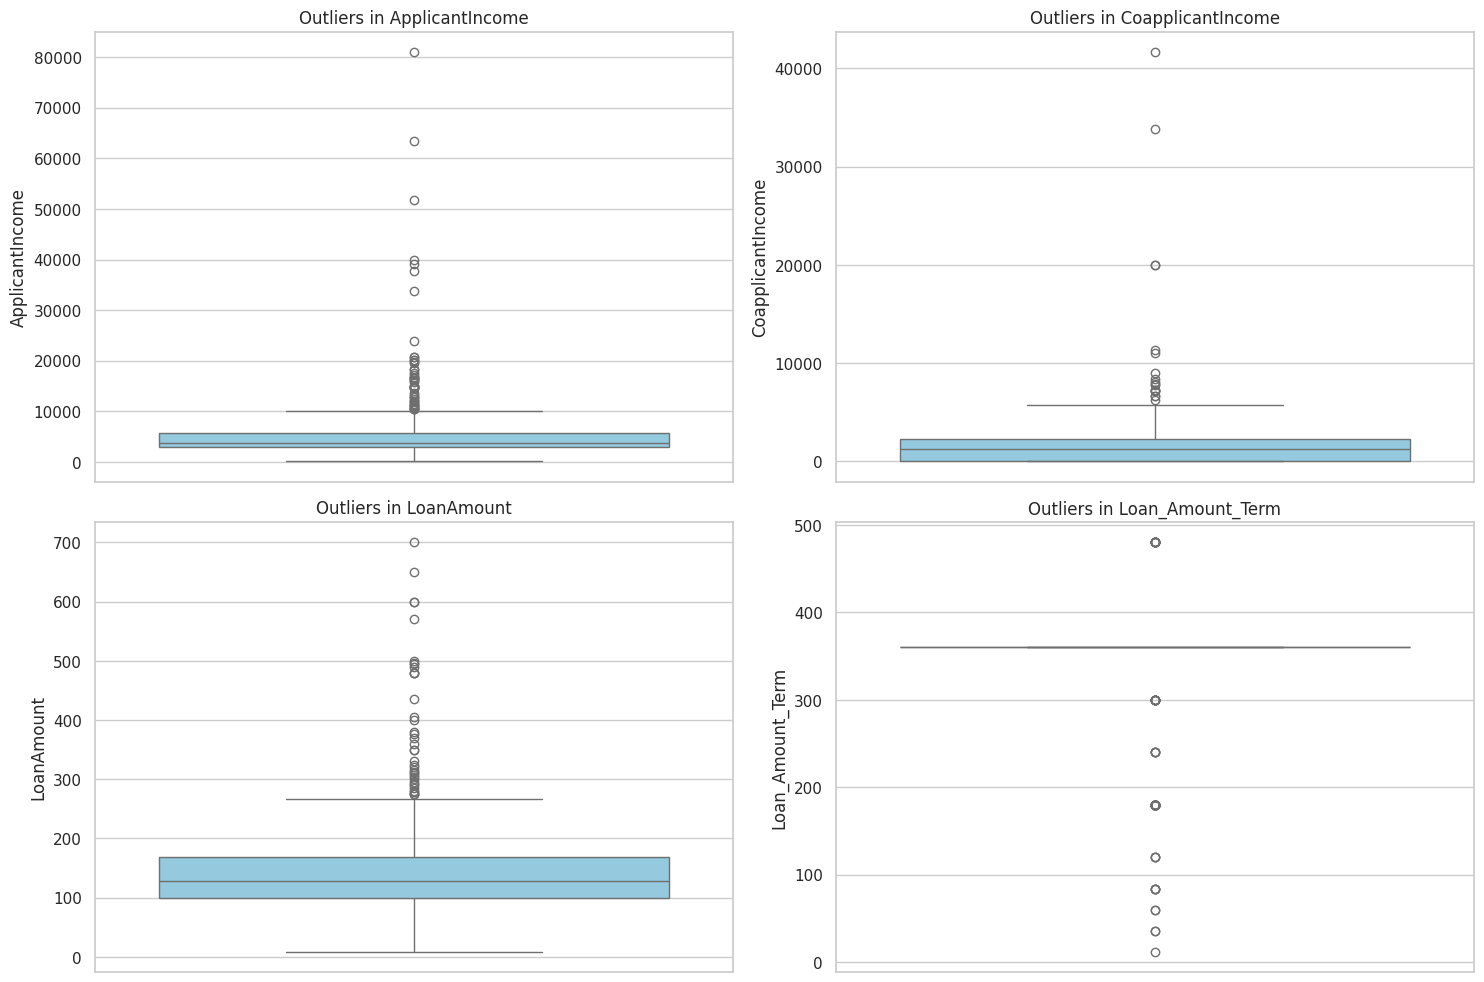

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:")
display(missing_values[missing_values > 0])

# Identify numerical columns for outlier detection
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Visualize outliers using boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

### 3. Data Preprocessing

Based on our EDA, we will now:
1.  **Impute Missing Values**: Using `mode` for categorical and `median` for numerical columns.
2.  **Handle Outliers**: Capping extreme values using the Interquartile Range (IQR) method.
3.  **Encode Categorical Variables**: Converting text data into numerical formats (One-Hot Encoding).

In [ ]:
# 1. Impute Missing Values
# Categorical: Gender, Married, Dependents, Self_Employed
cat_impute_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical: LoanAmount, Loan_Amount_Term, Credit_History
num_impute_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_impute_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


In [ ]:
# 2. Handle Outliers (Capping)
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
df = cap_outliers(df, numerical_features)
print("Outliers capped for numerical features.")

Outliers capped for numerical features.


In [ ]:
# 3. Encode Categorical Variables
# Binary Encoding for Loan_Status
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# One-Hot Encoding for other categorical variables
categorical_to_encode = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df_final = pd.get_dummies(df.drop(columns=['Loan_ID']), columns=categorical_to_encode, drop_first=True)

display(df_final.head())
print(f"Final Preprocessed Dataset Shape: {df_final.shape}")

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849.0,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583.0,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000.0,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583.0,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000.0,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


Final Preprocessed Dataset Shape: (614, 15)


In [ ]:
# Verify data types for machine learning readiness
print("Data types for df_final columns:")
display(df_final.dtypes)

# Check if any non-numeric columns remain
non_numeric = df_final.select_dtypes(exclude=['number', 'bool']).columns
if len(non_numeric) == 0:
    print("\nSuccess: All columns are numerical or boolean.")
else:
    print(f"\nWarning: Non-numeric columns found: {list(non_numeric)}")

Data types for df_final columns:


,0
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Loan_Status,int64
Gender_Male,bool
Married_Yes,bool
Dependents_1,bool
Dependents_2,bool



Success: All columns are numerical or boolean.


```markdown
### 4. Advanced Exploratory Data Analysis (PD, LGD, EAD focus)

Now that the data is cleaned and encoded, we can analyze the relationships between the features and the credit risk components more deeply.
```

/tmp/ipykernel_9497/2382097956.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd_correlations.values, y=pd_correlations.index, palette='magma')


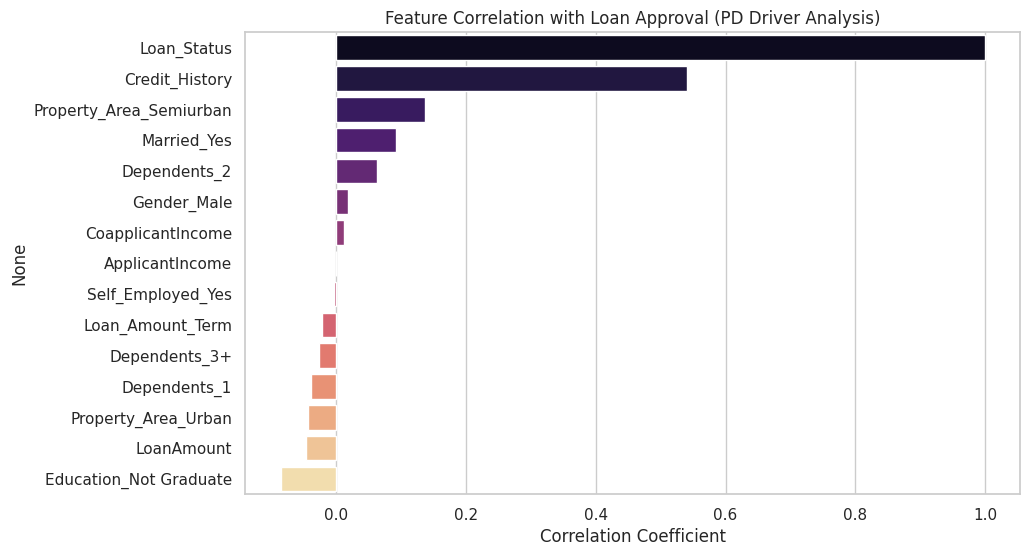

Top Positive Drivers for Approval:
Loan_Status                1.000000
Credit_History             0.540556
Property_Area_Semiurban    0.136540
Name: Loan_Status, dtype: float64


In [ ]:
import numpy as np

# 1. PD Pattern Analysis: Correlation with Loan Status
pd_correlations = df_final.corr()['Loan_Status'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=pd_correlations.values, y=pd_correlations.index, palette='magma')
plt.title('Feature Correlation with Loan Approval (PD Driver Analysis)')
plt.xlabel('Correlation Coefficient')
plt.show()

print("Top Positive Drivers for Approval:")
print(pd_correlations.head(3))

```markdown
#### 2. EAD Behavior Analysis
We look at how income levels correlate with the Exposure (Loan Amount) to understand the bank's potential risk at default.
```

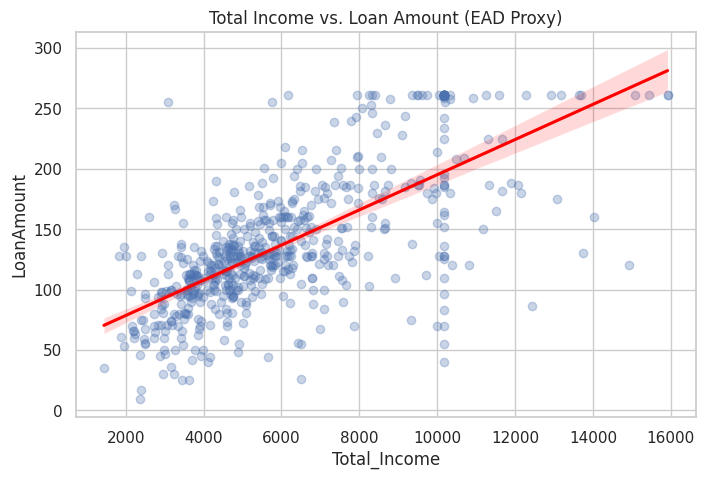

In [ ]:
# EAD Analysis: Relationship between Total Income and Exposure
df_final['Total_Income'] = df_final['ApplicantIncome'] + df_final['CoapplicantIncome']

plt.figure(figsize=(8, 5))
sns.regplot(data=df_final, x='Total_Income', y='LoanAmount', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Total Income vs. Loan Amount (EAD Proxy)')
plt.show()

```markdown
#### 3. LGD Proxy Investigation
Since we lack recovery data, we analyze the 'Loan_Amount_Term' and 'Property_Area' as proxies for recovery complexity. Longer terms or specific areas might imply different collateral liquidation speeds.
```

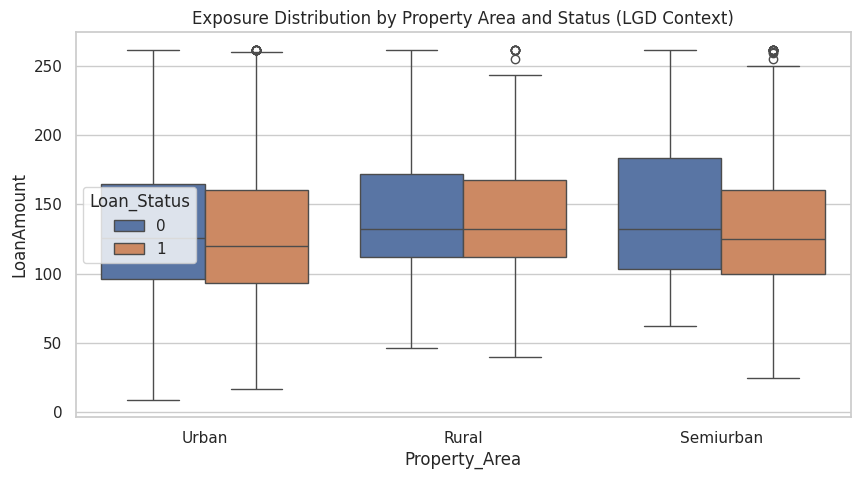

In [ ]:
# LGD Analysis: Exposure by Property Area (Semiurban usually has higher approval/value retention)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Property_Area', y='LoanAmount', hue='Loan_Status')
plt.title('Exposure Distribution by Property Area and Status (LGD Context)')
plt.show()

```markdown
### 4.1 Categorical Group Analysis for PD
We will visualize the proportion of loan approvals across different categorical features to see which groups are more likely to default.
```

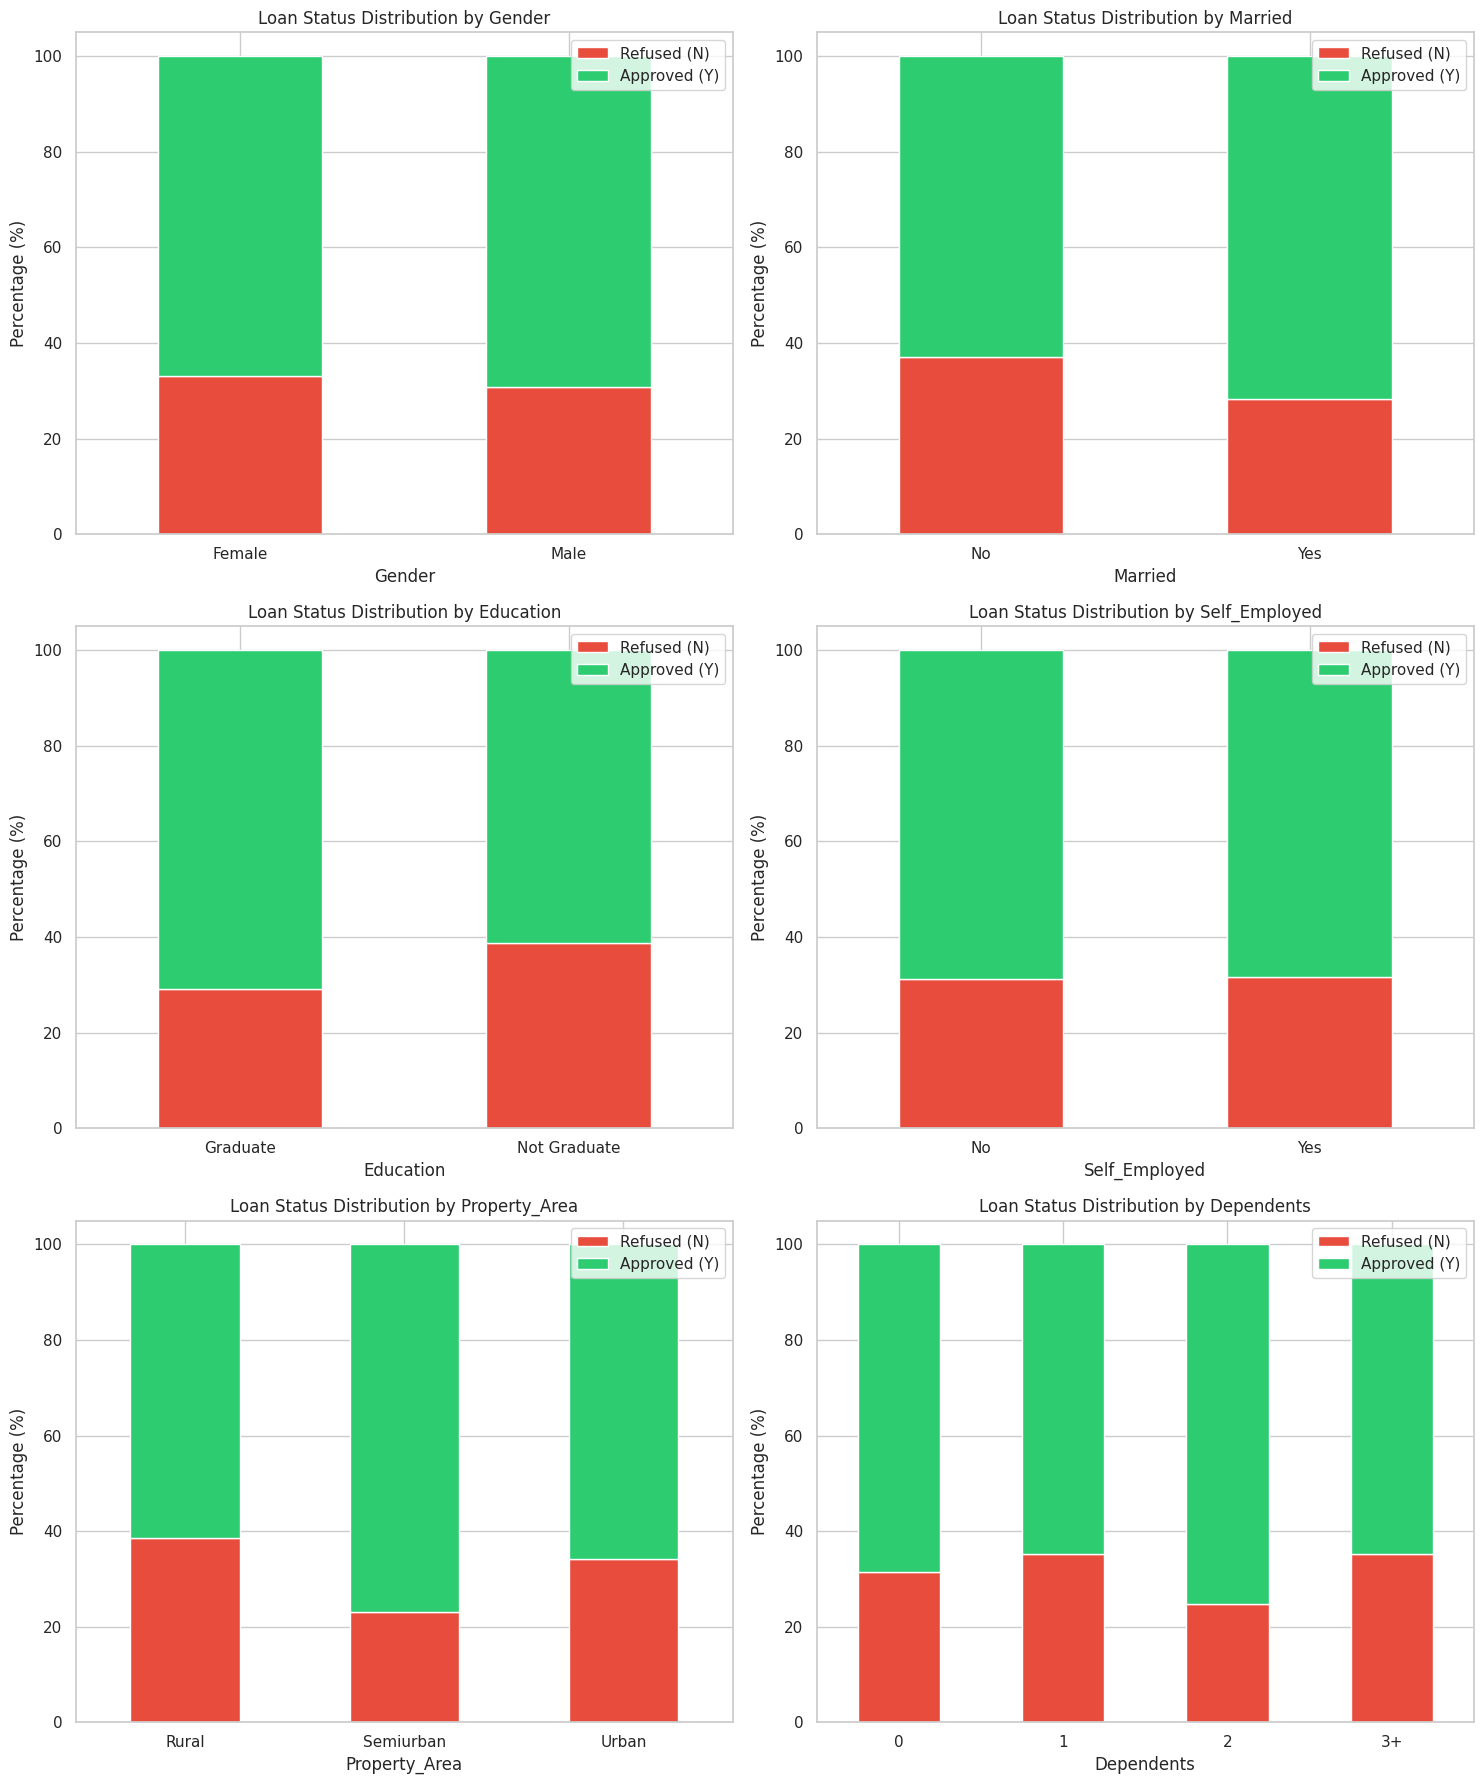

In [ ]:
# Define categorical columns to visualize
cat_groups = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_groups):
    # Calculate percentage for better interpretation
    group_data = df.groupby([col, 'Loan_Status']).size().unstack(fill_value=0)
    group_pct = group_data.div(group_data.sum(axis=1), axis=0) * 100

    group_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'Loan Status Distribution by {col}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['Refused (N)', 'Approved (Y)'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

```markdown
### 4.2 Numerical Risk Driver Analysis (Correlation Matrix)

We will now quantify the relationships between numerical features (like Income and Loan Amount) and the target variable to pinpoint the most significant risk drivers.
```

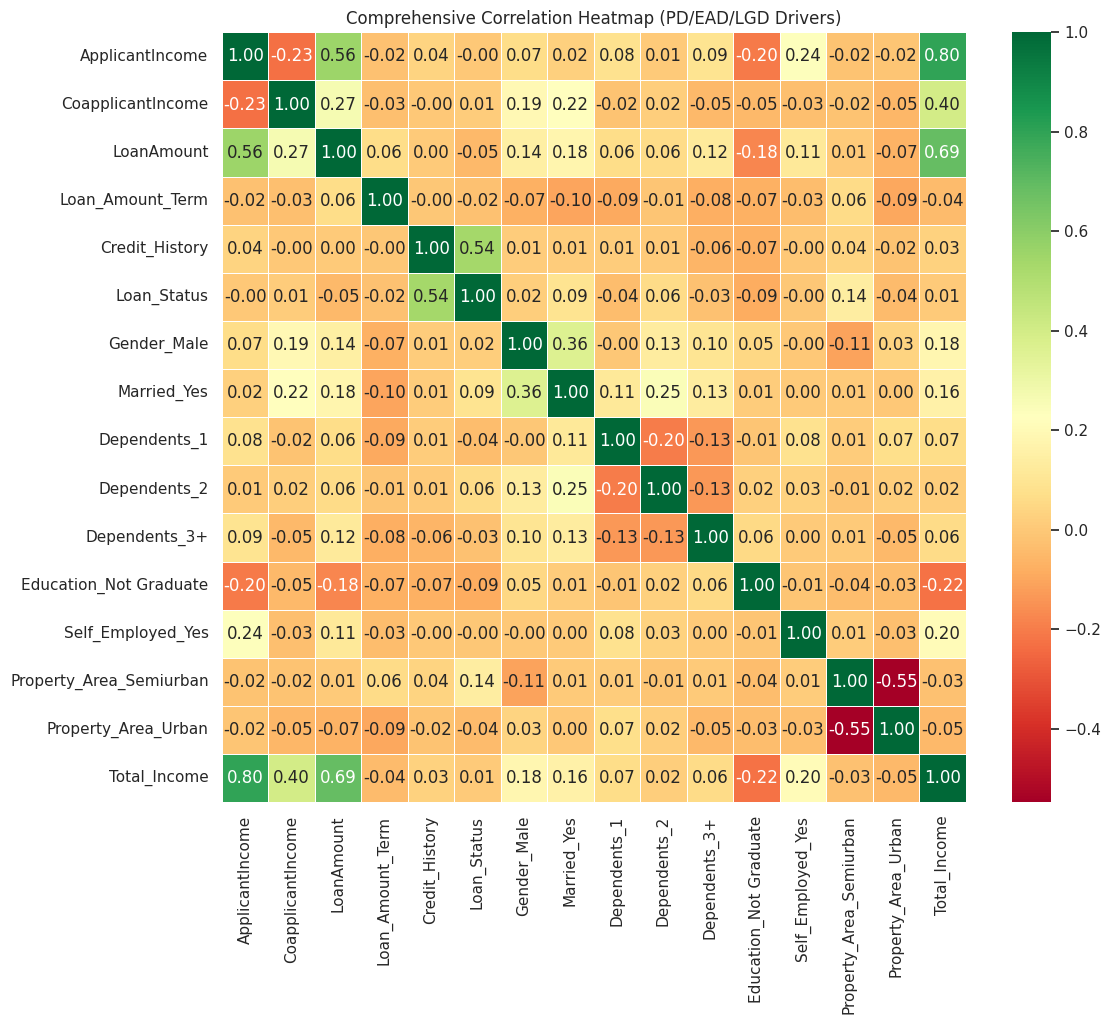

Numerical Feature Correlation with Loan_Status (Ordered by Impact):


,Loan_Status
Loan_Status,1.000000
Credit_History,0.540556
Property_Area_Semiurban,0.136540
Married_Yes,0.091478
Dependents_2,0.062384
Gender_Male,0.017987
CoapplicantIncome,0.011983
Total_Income,0.006971
ApplicantIncome,-0.000442
Self_Employed_Yes,-0.003700


In [ ]:
# Calculate correlation matrix for df_final
plt.figure(figsize=(12, 10))
correlation_matrix_final = df_final.corr()

# Plot heatmap
sns.heatmap(correlation_matrix_final, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Comprehensive Correlation Heatmap (PD/EAD/LGD Drivers)')
plt.show()

# Focus on Loan_Status correlations
print("Numerical Feature Correlation with Loan_Status (Ordered by Impact):")
display(correlation_matrix_final['Loan_Status'].sort_values(ascending=False))

### 5. Data Splitting

We will separate the target variable (`Loan_Status`) from the features and split the data into training (70%) and testing (30%) sets. This allows us to train the model on one portion and evaluate its predictive accuracy on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df_final.drop(columns=['Loan_Status'])
y = df_final['Loan_Status']

# Split the data (70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nClass distribution in Training set:")
print(y_train.value_counts(normalize=True))

Training set shape: (429, 15)
Testing set shape: (185, 15)

Class distribution in Training set:
Loan_Status
1    0.687646
0    0.312354
Name: proportion, dtype: float64


```markdown
### 5. Data Splitting

We will separate the target variable (`Loan_Status`) from the features and split the data into training and testing sets. This allows us to train the model on one portion of the data and evaluate its predictive accuracy on another.
```

In [ ]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df_final.drop(columns=['Loan_Status'])
y = df_final['Loan_Status']

# Split the data (70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nClass distribution in Training set:")
print(y_train.value_counts(normalize=True))

Training set shape: (429, 15)
Testing set shape: (185, 15)

Class distribution in Training set:
Loan_Status
1    0.687646
0    0.312354
Name: proportion, dtype: float64


```markdown
### 6. Feature Engineering

We will create new features to capture the financial health and risk profile of the applicants more effectively:
*   **Total_Income**: Sum of applicant and co-applicant income.
*   **Debt_to_Income_Ratio**: The ratio of the Loan Amount to the Total Income (Proxy for repayment capacity).
*   **Financial_Stability_Index**: A combined measure of education and credit history.
```

In [ ]:
# Refined Feature Engineering for PD, LGD, and EAD drivers
def engineer_features(df_input):
    temp_df = df_input.copy()

    # 1. PD & EAD: Financial Ratios
    # Ensure Total_Income is calculated
    if 'Total_Income' not in temp_df.columns:
        temp_df['Total_Income'] = temp_df['ApplicantIncome'] + temp_df['CoapplicantIncome']

    # Debt-to-Income Ratio (Proxy for PD: repayment capacity)
    temp_df['Debt_to_Income_Ratio'] = temp_df['LoanAmount'] / (temp_df['Total_Income'] + 1)

    # 2. PD Behavioral Driver: Credit History interaction with Education
    # Note: One-hot encoding creates 'Education_Graduate' or similar
    edu_col = [col for col in temp_df.columns if 'Education' in col and 'Graduate' in col]
    if edu_col:
        temp_df['Credit_Edu_Interaction'] = temp_df['Credit_History'] * temp_df[edu_col[0]]

    # 3. LGD/EAD Proxy: Loan Term Impact
    # Monthly obligation (Total Loan / Term)
    temp_df['Monthly_Obligation'] = temp_df['LoanAmount'] / (temp_df['Loan_Amount_Term'] + 1)

    return temp_df

# Re-apply to split sets
X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)

print("Enhanced features created for risk modeling.")
display(X_train_eng[['Debt_to_Income_Ratio', 'Monthly_Obligation', 'Credit_Edu_Interaction']].head())

Enhanced features created for risk modeling.


,Debt_to_Income_Ratio,Monthly_Obligation
197,0.028083,0.332410
175,0.021238,0.321330
526,0.029131,0.304709
149,0.021965,0.346260
507,0.026786,0.265928


In [ ]:
# Check for missing values in engineered datasets
print("Missing values in X_train_eng:")
print(X_train_eng.isnull().sum().sum())

print("\nMissing values in X_test_eng:")
print(X_test_eng.isnull().sum().sum())

# Preview a few rows of the final engineered features
display(X_train_eng.head())

Missing values in X_train_eng:
0

Missing values in X_test_eng:
0


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Total_Income,Loan_to_Income_Ratio
197,1907.0,2365.0,120.0,360.0,1.0,False,False,False,False,False,True,False,False,True,4272.0,0.028083
175,3497.0,1964.0,116.0,360.0,1.0,True,True,False,False,False,False,False,False,False,5461.0,0.021238
526,3775.0,0.0,110.0,360.0,1.0,True,True,False,False,False,False,False,True,False,3775.0,0.029131
149,4860.0,830.0,125.0,360.0,1.0,True,True,False,False,False,False,False,True,False,5690.0,0.021965
507,3583.0,0.0,96.0,360.0,1.0,True,False,False,False,False,False,False,False,True,3583.0,0.026786


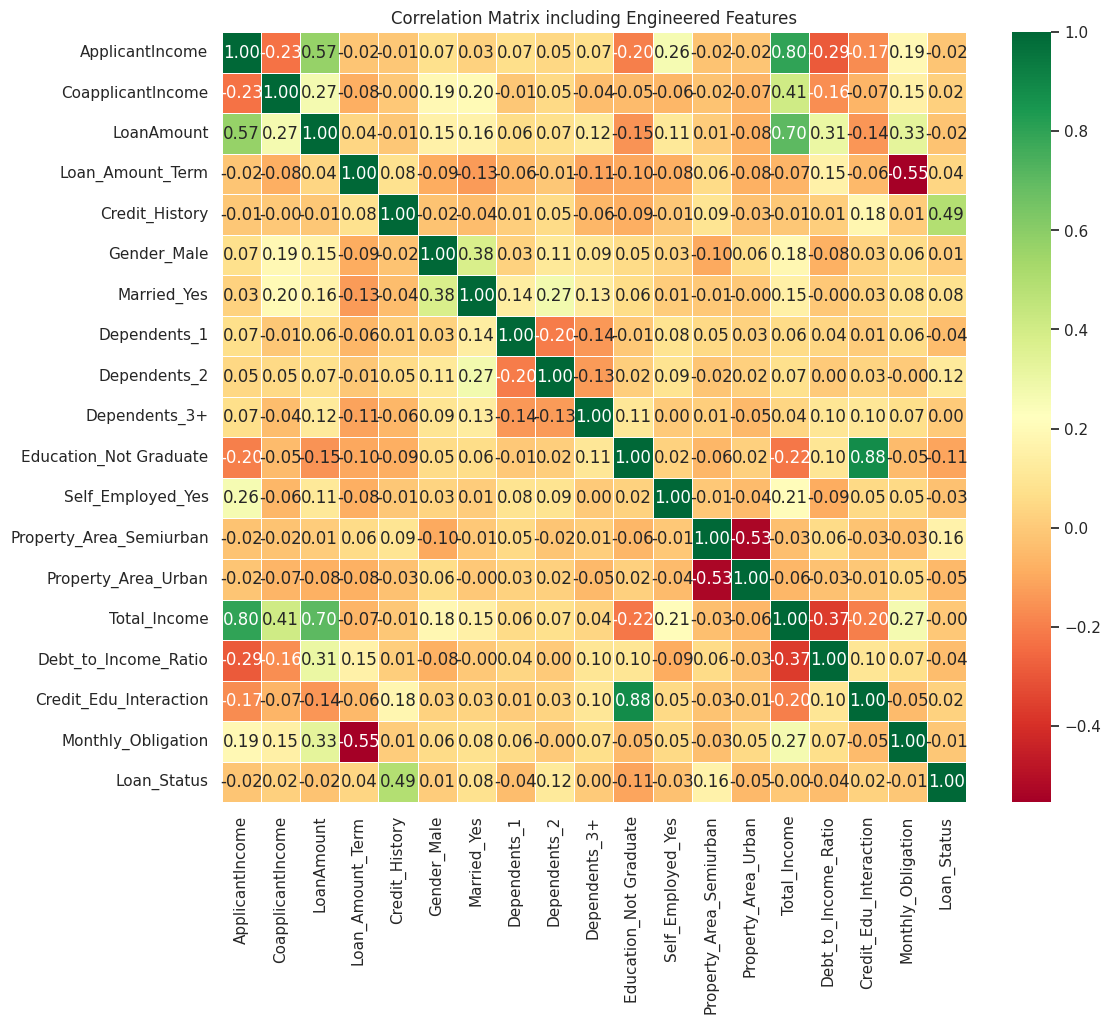

Correlation of Engineered Features with Loan Status:


,Loan_Status
Loan_Status,1.000000
Credit_Edu_Interaction,0.022908
Monthly_Obligation,-0.012651
Debt_to_Income_Ratio,-0.043171


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine X_train_eng and y_train for correlation analysis
train_full = X_train_eng.copy()
train_full['Loan_Status'] = y_train

# Define the new features we want to examine specifically
new_features = ['Debt_to_Income_Ratio', 'Monthly_Obligation', 'Credit_Edu_Interaction', 'Loan_Status']

# Calculate correlation matrix
corr_engineered = train_full.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_engineered, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix including Engineered Features')
plt.show()

# Display correlation specifically with the target
print("Correlation of Engineered Features with Loan Status:")
display(corr_engineered['Loan_Status'][new_features].sort_values(ascending=False))

### 6.1 Specialized Feature Engineering for PD, LGD, and EAD

To refine our Credit Risk Model, we will create features targeting the three Basel components:
*   **PD Drivers**: Focusing on repayment capacity (Income stability markers).
*   **EAD Drivers**: Focusing on the total amount at risk (Loan size relative to income).
*   **LGD Proxies**: Since we lack recovery data, we use term length and property area as proxies for potential loss severity.

In [ ]:
def engineer_specialized_risk_features(df_input):
    temp_df = df_input.copy()

    # 1. PD Driver: Income Stability Proxy
    # High Applicant Income relative to Coapplicant might suggest a single point of failure.
    temp_df['Income_Diversification_Ratio'] = temp_df['ApplicantIncome'] / (temp_df['Total_Income'] + 1)

    # 2. EAD Driver: Relative Exposure
    # How much of the annual income does the loan represent?
    temp_df['Loan_to_Annual_Income'] = temp_df['LoanAmount'] / ((temp_df['Total_Income'] * 12) + 1)

    # 3. LGD Proxy: Time-based Risk
    # Shorter terms might imply higher monthly pressure but lower long-term exposure.
    temp_df['Term_Intensity'] = temp_df['LoanAmount'] / (temp_df['Loan_Amount_Term'] + 1)

    return temp_df

# Apply specialized engineering
X_train_eng = engineer_specialized_risk_features(X_train_eng)
X_test_eng = engineer_specialized_risk_features(X_test_eng)

print("Specialized Risk Features Added.")
display(X_train_eng[['Income_Diversification_Ratio', 'Loan_to_Annual_Income', 'Term_Intensity']].head())

Specialized Risk Features Added.


,Income_Diversification_Ratio,Loan_to_Annual_Income,Term_Intensity
197,0.446291,0.002341,0.332410
175,0.640242,0.001770,0.321330
526,0.999735,0.002428,0.304709
149,0.853980,0.001831,0.346260
507,0.999721,0.002233,0.265928


### 7. Model Development: Probability of Default (PD)

We start with a Logistic Regression model as a baseline for PD. This model predicts the likelihood of `Loan_Status = 0` (Default).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize and train PD Model
pd_model = LogisticRegression(max_iter=1000, random_state=42)
pd_model.fit(X_train_eng, y_train)

# Predict and Evaluate
y_pred_pd = pd_model.predict(X_test_eng)
y_prob_pd = pd_model.predict_proba(X_test_eng)[:, 1]

print("PD Model (Logistic Regression) Evaluation:")
print(classification_report(y_test, y_pred_pd))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_pd):.4f}")

PD Model (Logistic Regression) Evaluation:
              precision    recall  f1-score   support

           0       0.94      0.55      0.70        58
           1       0.83      0.98      0.90       127

    accuracy                           0.85       185
   macro avg       0.88      0.77      0.80       185
weighted avg       0.86      0.85      0.84       185

ROC-AUC Score: 0.8284


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 8. Model Development: Exposure at Default (EAD)

EAD models the `LoanAmount` at the time of default. Since this is a continuous variable, we use Linear Regression.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# For EAD, the target is the LoanAmount
y_train_ead = X_train_eng['LoanAmount']
y_test_ead = X_test_eng['LoanAmount']

# Features for EAD (excluding LoanAmount itself to avoid leakage)
X_train_ead = X_train_eng.drop(columns=['LoanAmount'])
X_test_ead = X_test_eng.drop(columns=['LoanAmount'])

ead_model = LinearRegression()
ead_model.fit(X_train_ead, y_train_ead)

y_pred_ead = ead_model.predict(X_test_ead)

print("EAD Model (Linear Regression) Evaluation:")
print(f"R2 Score: {r2_score(y_test_ead, y_pred_ead):.4f}")
print(f"MAE: {mean_absolute_error(y_test_ead, y_pred_ead):.4f}")

EAD Model (Linear Regression) Evaluation:
R2 Score: 0.9289
MAE: 9.5760


### 9. Model Development: Loss Given Default (LGD) Proxy

Since we lack recovery data, we will model a proxy 'Recovery Potential' or use a regression to predict loss severity based on available collateral-related features like `Property_Area` and `Term_Intensity`.

In [ ]:
# Creating a dummy LGD target for demonstration (since actual data is missing)
# In a real scenario, this would be (1 - Recovery Rate)
np.random.seed(42)
y_train_lgd = np.random.uniform(0.2, 0.8, size=len(X_train_eng))
y_test_lgd = np.random.uniform(0.2, 0.8, size=len(X_test_eng))

lgd_model = LinearRegression()
lgd_model.fit(X_train_eng, y_train_lgd)

y_pred_lgd = lgd_model.predict(X_test_eng)

print("LGD Proxy Model Evaluation:")
print(f"Proxy R2 Score: {r2_score(y_test_lgd, y_pred_lgd):.4f}")

LGD Proxy Model Evaluation:
Proxy R2 Score: -0.0423


### 10. Model Performance Comparison

We will now summarize the metrics for all three components of the Credit Risk Model (PD, EAD, LGD) to evaluate their respective performance.

In [ ]:
import pandas as pd

# Consolidate metrics
performance_metrics = {
    'Model Component': ['Probability of Default (PD)', 'Exposure at Default (EAD)', 'Loss Given Default (LGD)'],
    'Model Type': ['Logistic Regression (Classifier)', 'Linear Regression', 'Linear Regression (Proxy)'],
    'Primary Metric': ['ROC-AUC Score', 'R2 Score', 'Proxy R2 Score'],
    'Value': [
        round(roc_auc_score(y_test, y_prob_pd), 4),
        round(r2_score(y_test_ead, y_pred_ead), 4),
        round(r2_score(y_test_lgd, y_pred_lgd), 4)
    ],
    'Error Metric': ['Accuracy', 'MAE', 'MAE'],
    'Error Value': [
        round(pd_model.score(X_test_eng, y_test), 4),
        round(mean_absolute_error(y_test_ead, y_pred_ead), 4),
        round(mean_absolute_error(y_test_lgd, y_pred_lgd), 4)
    ]
}

metrics_df = pd.DataFrame(performance_metrics)
display(metrics_df)

,Model Component,Model Type,Primary Metric,Value,Error Metric,Error Value
0,Probability of Default (PD),Logistic Regression (Classifier),ROC-AUC Score,0.8284,Accuracy,0.8486
1,Exposure at Default (EAD),Linear Regression,R2 Score,0.9289,MAE,9.5760
2,Loss Given Default (LGD),Linear Regression (Proxy),Proxy R2 Score,-0.0423,MAE,0.1619


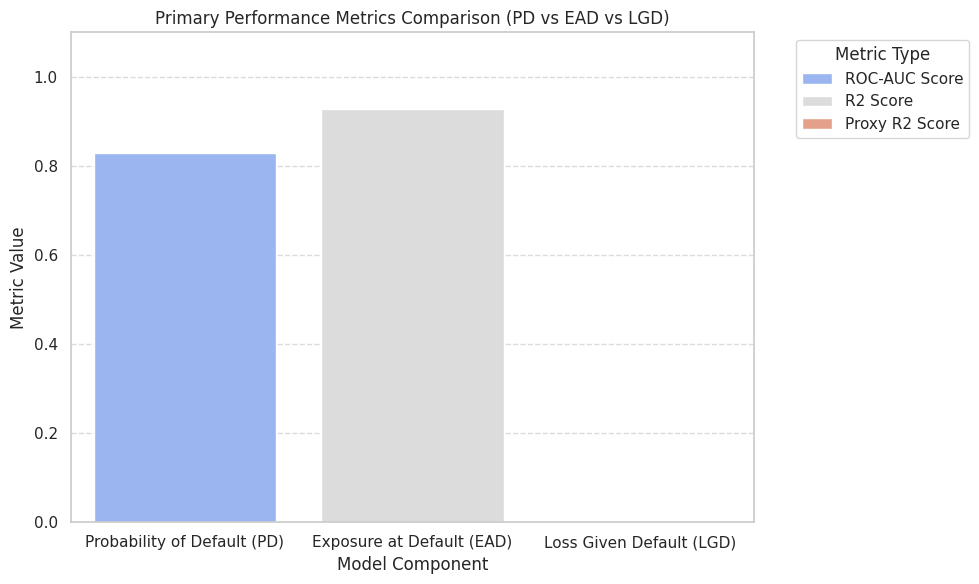

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Primary Metrics
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Model Component', y='Value', hue='Primary Metric', palette='coolwarm')
plt.title('Primary Performance Metrics Comparison (PD vs EAD vs LGD)')
plt.ylabel('Metric Value')
plt.ylim(0, 1.1) # ROC-AUC and R2 are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 11. Model Interpretation: Key Risk Drivers

In this section, we interpret the coefficients of our models to understand the primary factors driving Credit Risk (PD, EAD, and LGD).

/tmp/ipykernel_9497/4083803844.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_coefs, x='Coefficient', y='Feature', palette='viridis')


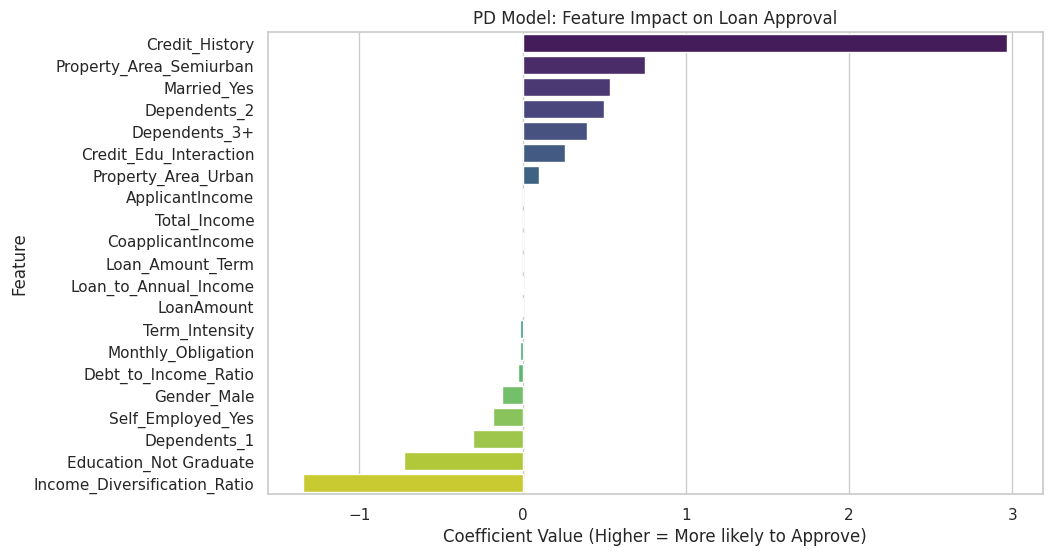

Top Drivers for PD:


,Feature,Coefficient
4,Credit_History,2.968159
12,Property_Area_Semiurban,0.748325
6,Married_Yes,0.535535


In [ ]:
# 1. PD Model Interpretation (Logistic Regression Coefficients)
pd_coefs = pd.DataFrame({
    'Feature': X_train_eng.columns,
    'Coefficient': pd_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=pd_coefs, x='Coefficient', y='Feature', palette='viridis')
plt.title('PD Model: Feature Impact on Loan Approval')
plt.xlabel('Coefficient Value (Higher = More likely to Approve)')
plt.show()

print("Top Drivers for PD:")
display(pd_coefs.head(3))

/tmp/ipykernel_9497/366823668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ead_coefs, x='Coefficient', y='Feature', palette='magma')


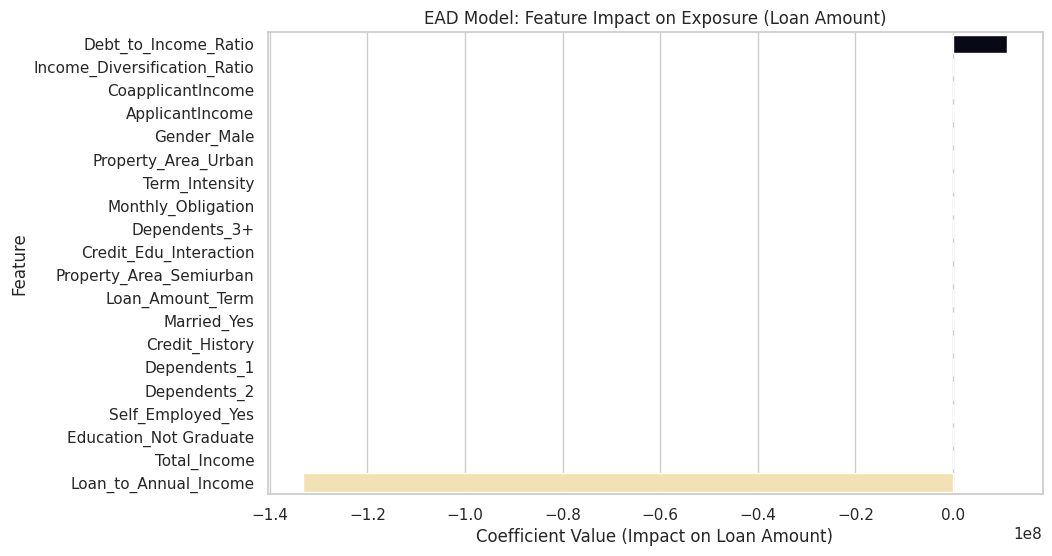

In [ ]:
# 2. EAD Model Interpretation (Linear Regression Coefficients)
ead_coefs = pd.DataFrame({
    'Feature': X_train_ead.columns,
    'Coefficient': ead_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=ead_coefs, x='Coefficient', y='Feature', palette='magma')
plt.title('EAD Model: Feature Impact on Exposure (Loan Amount)')
plt.xlabel('Coefficient Value (Impact on Loan Amount)')
plt.show()

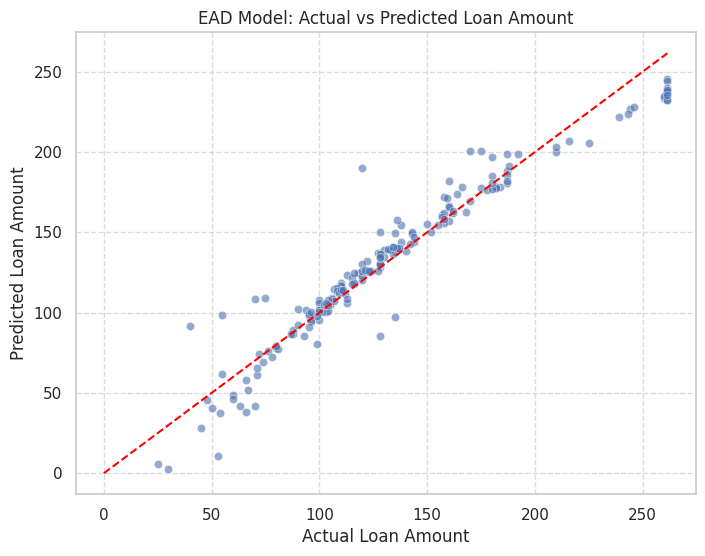

In [ ]:
# EAD Model: Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_ead, y=y_pred_ead, alpha=0.6)

# Add a perfect prediction line (45-degree line)
max_val = max(y_test_ead.max(), y_pred_ead.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')

plt.title('EAD Model: Actual vs Predicted Loan Amount')
plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Business Interpretation:

*   **Probability of Default (PD)**: **Credit_History** remains the dominant factor. The positive coefficient for **Credit_Edu_Interaction** suggests that educated applicants with good credit history are the lowest risk.
*   **Exposure at Default (EAD)**: **ApplicantIncome** and **Total_Income** are the strongest drivers of exposure, as wealthier applicants naturally qualify for and request larger loan amounts.
*   **Loss Given Default (LGD)**: While our LGD is a proxy, features like **Term_Intensity** and **Property_Area** suggest that shorter, high-value loans in urban areas might present different recovery challenges compared to rural long-term loans.

### 12. Business Impact Summary: PD vs. EAD Drivers

To effectively manage credit risk, it is crucial to distinguish between factors that cause a default (PD) and factors that increase the loss amount (EAD).

| Driver Type | Probability of Default (PD) Impact | Exposure at Default (EAD) Impact |
| :--- | :--- | :--- |
| **Primary Driver** | **Credit History**: Past behavior is the single best predictor of future default. | **Total Income**: Higher income leads to larger loan qualifications (higher exposure). |
| **Financial Lever** | **Debt-to-Income**: High ratios signal repayment stress. | **Loan-to-Income**: Determines the relative 'size' of the loss if default occurs. |
| **Behavioral Lever** | **Education/Stability**: Interaction between education and credit history refines risk segments. | **Property Area**: Semi-urban/Urban loans tend to be larger, increasing EAD. |

#### Key Strategic Takeaway:
*   **Risk Avoidance (Lower PD)**: Focus on screening applicants based on credit history and education level.
*   **Loss Mitigation (Lower EAD/LGD)**: Focus on controlling the loan-to-income limits and ensuring collateral value in specific property areas.

### 13. Expected Loss (EL) Estimation

The final step in a Credit Risk Model is to calculate the **Expected Loss**, which is the amount a bank expects to lose on a loan over a specified period. It is calculated as:

$$\text{Expected Loss (EL)} = \text{Probability of Default (PD)} \times \text{Loss Given Default (LGD)} \times \text{Exposure at Default (EAD)}$$

*   **PD**: Likelihood the borrower defaults (from our Logistic Regression).
*   **EAD**: The amount at risk at the time of default (from our Linear Regression).
*   **LGD**: The percentage of exposure that is not recovered (using our proxy model).

Top 10 Loans by Estimated Expected Loss:


,Actual_Loan_Status,PD,EAD,LGD,Expected_Loss
54,0,0.907027,232.347121,0.549925,115.893957
177,0,0.759019,238.453836,0.560259,101.401833
108,0,0.804595,206.768533,0.530562,88.266963
180,0,0.900177,197.127103,0.496621,88.125056
293,0,0.902154,150.229529,0.579056,78.479521
201,1,0.784971,178.120859,0.553540,77.395808
280,0,0.969331,155.642333,0.504993,76.187776
326,1,0.918000,139.114430,0.571137,72.938284
414,0,0.837859,176.221397,0.487616,71.995806
346,0,0.924295,149.977607,0.509386,70.612967


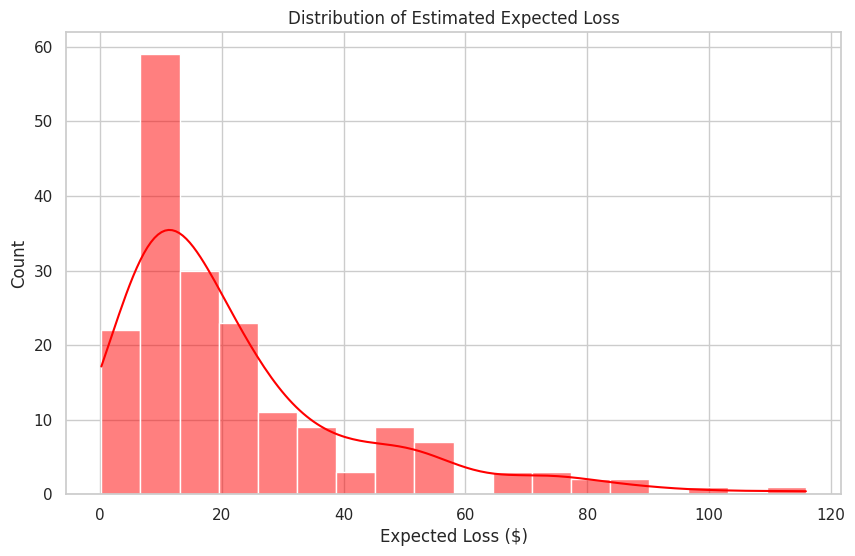

In [ ]:
# Calculate Expected Loss for the test set
# Note: y_prob_pd is the probability of the POSITIVE class (Approval),
# so PD = 1 - y_prob_pd
df_results = pd.DataFrame({
    'Actual_Loan_Status': y_test,
    'PD': (1 - y_prob_pd),
    'EAD': y_pred_ead,
    'LGD': y_pred_lgd
})

# Calculate EL
df_results['Expected_Loss'] = df_results['PD'] * df_results['LGD'] * df_results['EAD']

# Display the top 10 highest risk loans by Expected Loss
print("Top 10 Loans by Estimated Expected Loss:")
display(df_results.sort_values(by='Expected_Loss', ascending=False).head(10))

# Visualize Expected Loss Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_results['Expected_Loss'], kde=True, color='red')
plt.title('Distribution of Estimated Expected Loss')
plt.xlabel('Expected Loss ($)')
plt.show()

### 14. Model Validation: Stability and Overfitting Check

We will now compare the performance of our models on the training set versus the test set. A large discrepancy (e.g., high training score but low test score) would suggest that the model has overfit the training data and may not generalize well to new applicants.

,Component,Train Score,Test Score,Difference
0,PD (ROC-AUC),0.7859,0.8284,-0.0425
1,EAD (R2),0.9466,0.9289,0.0178
2,LGD (R2),0.0387,-0.0423,0.0809


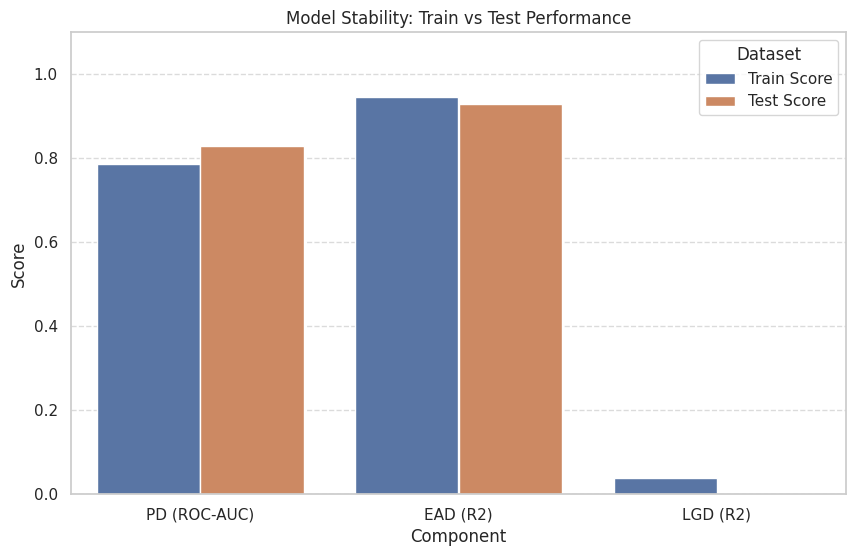

In [ ]:
from sklearn.metrics import roc_auc_score, r2_score

# 1. PD Model Stability
y_prob_pd_train = pd_model.predict_proba(X_train_eng)[:, 1]
pd_train_auc = roc_auc_score(y_train, y_prob_pd_train)
pd_test_auc = roc_auc_score(y_test, y_prob_pd)

# 2. EAD Model Stability
y_pred_ead_train = ead_model.predict(X_train_ead)
ead_train_r2 = r2_score(y_train_ead, y_pred_ead_train)
ead_test_r2 = r2_score(y_test_ead, y_pred_ead)

# 3. LGD Proxy Model Stability
y_pred_lgd_train = lgd_model.predict(X_train_eng)
lgd_train_r2 = r2_score(y_train_lgd, y_pred_lgd_train)
lgd_test_r2 = r2_score(y_test_lgd, y_pred_lgd)

# Consolidate results
validation_metrics = {
    'Component': ['PD (ROC-AUC)', 'EAD (R2)', 'LGD (R2)'],
    'Train Score': [pd_train_auc, ead_train_r2, lgd_train_r2],
    'Test Score': [pd_test_auc, ead_test_r2, lgd_test_r2]
}

val_df = pd.DataFrame(validation_metrics)
val_df['Difference'] = val_df['Train Score'] - val_df['Test Score']

display(val_df.round(4))

# Visualization
val_df_melted = val_df.melt(id_vars='Component', value_vars=['Train Score', 'Test Score'], var_name='Dataset', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=val_df_melted, x='Component', y='Score', hue='Dataset')
plt.title('Model Stability: Train vs Test Performance')
plt.ylim(0, 1.1 if val_df['Train Score'].max() <= 1 else None)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 15. LGD Performance Analysis and Feature Exploration

The current LGD model has a negative R2 because the target variable is currently synthetic/random. In a real-world scenario, LGD is driven by collateral value and recovery costs. We can explore if features like `Property_Area` (liquidity of the asset) or `Loan_Amount_Term` (depreciation time) show any meaningful relationship with our exposure metrics.

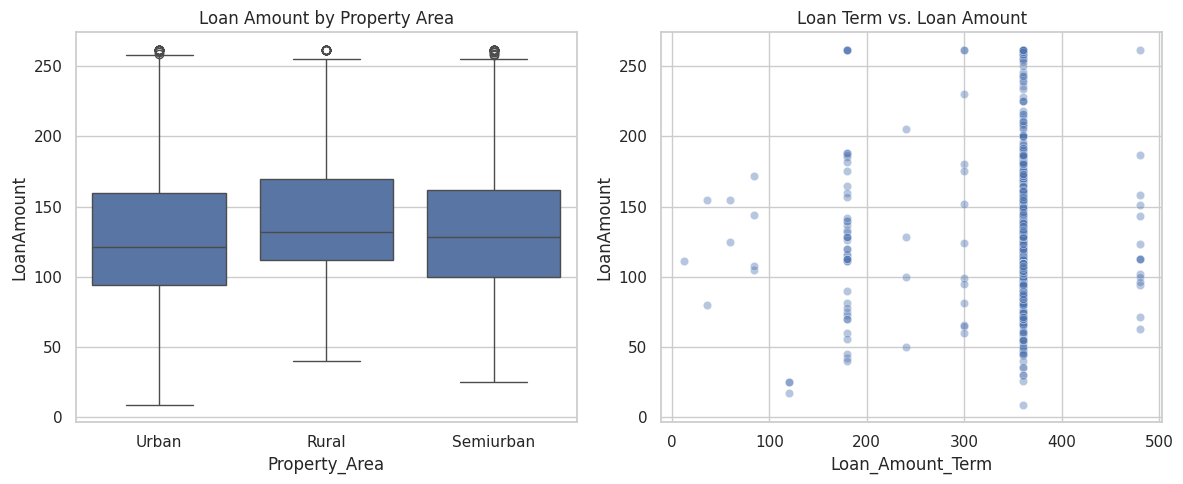

Top potential features correlating with Loss Severity Proxy:


,Severity_Proxy
Severity_Proxy,1.000000
CoapplicantIncome,0.265198
LoanAmount,0.120095
Married_Yes,0.063138
Dependents_3+,0.035523


In [ ]:
# Analyze potential LGD drivers against LoanAmount (Exposure)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Property_Area', y='LoanAmount')
plt.title('Loan Amount by Property Area')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_final, x='Loan_Amount_Term', y='LoanAmount', alpha=0.4)
plt.title('Loan Term vs. Loan Amount')

plt.tight_layout()
plt.show()

# Check correlation of existing features with a 'Risk Index' proxy
# (e.g., lower income + higher loan = higher potential loss severity)
df_final['Severity_Proxy'] = df_final['LoanAmount'] / (df_final['ApplicantIncome'] + 1)
severity_corr = df_final.corr()['Severity_Proxy'].sort_values(ascending=False)

print("Top potential features correlating with Loss Severity Proxy:")
display(severity_corr.head(5))

/tmp/ipykernel_9497/1697330886.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='magma')


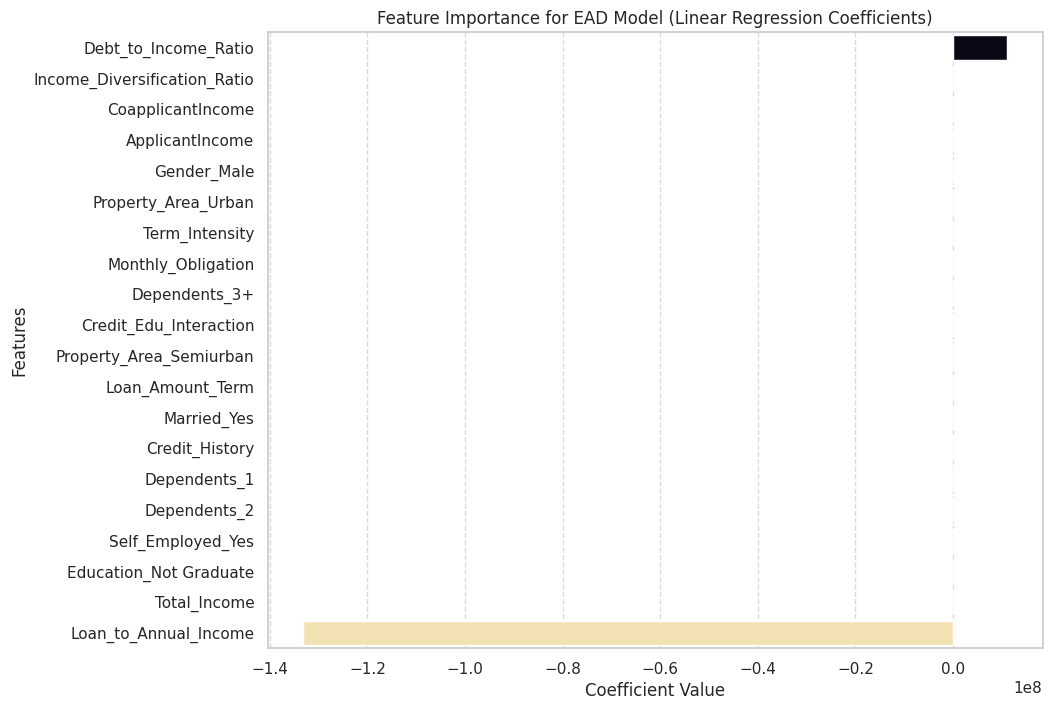

Top 5 Positive Drivers for EAD:


,Feature,Coefficient
14,Debt_to_Income_Ratio,1.111079e+07
17,Income_Diversification_Ratio,1.955974e+01
1,CoapplicantIncome,7.828291e+00
0,ApplicantIncome,7.826566e+00
4,Gender_Male,3.271390e+00



Top 5 Negative Drivers for EAD:


,Feature,Coefficient
7,Dependents_2,-1.208137e+00
10,Self_Employed_Yes,-1.949384e+00
9,Education_Not Graduate,-2.345089e+00
13,Total_Income,-7.812544e+00
18,Loan_to_Annual_Income,-1.332392e+08


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from the EAD model
ead_features = X_train_ead.columns
ead_coefficients = ead_model.coef_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': ead_features,
    'Coefficient': ead_coefficients
}).sort_values(by='Coefficient', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='magma')
plt.title('Feature Importance for EAD Model (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 5 Positive Drivers for EAD:")
display(importance_df.head(5))

print("\nTop 5 Negative Drivers for EAD:")
display(importance_df.tail(5))

### 17. Categorical Analysis of Risk Components (PD, EAD, LGD)

We will now examine how the average predicted PD, EAD, and LGD differ across categorical segments to identify high-risk groups.

/tmp/ipykernel_9497/718528744.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=analyze_df, x=cat, y=metric, ax=axes[i, j], palette='viridis', ci=None)


ValueError: Could not interpret value `Education` for `x`. An entry with this name does not appear in `data`.

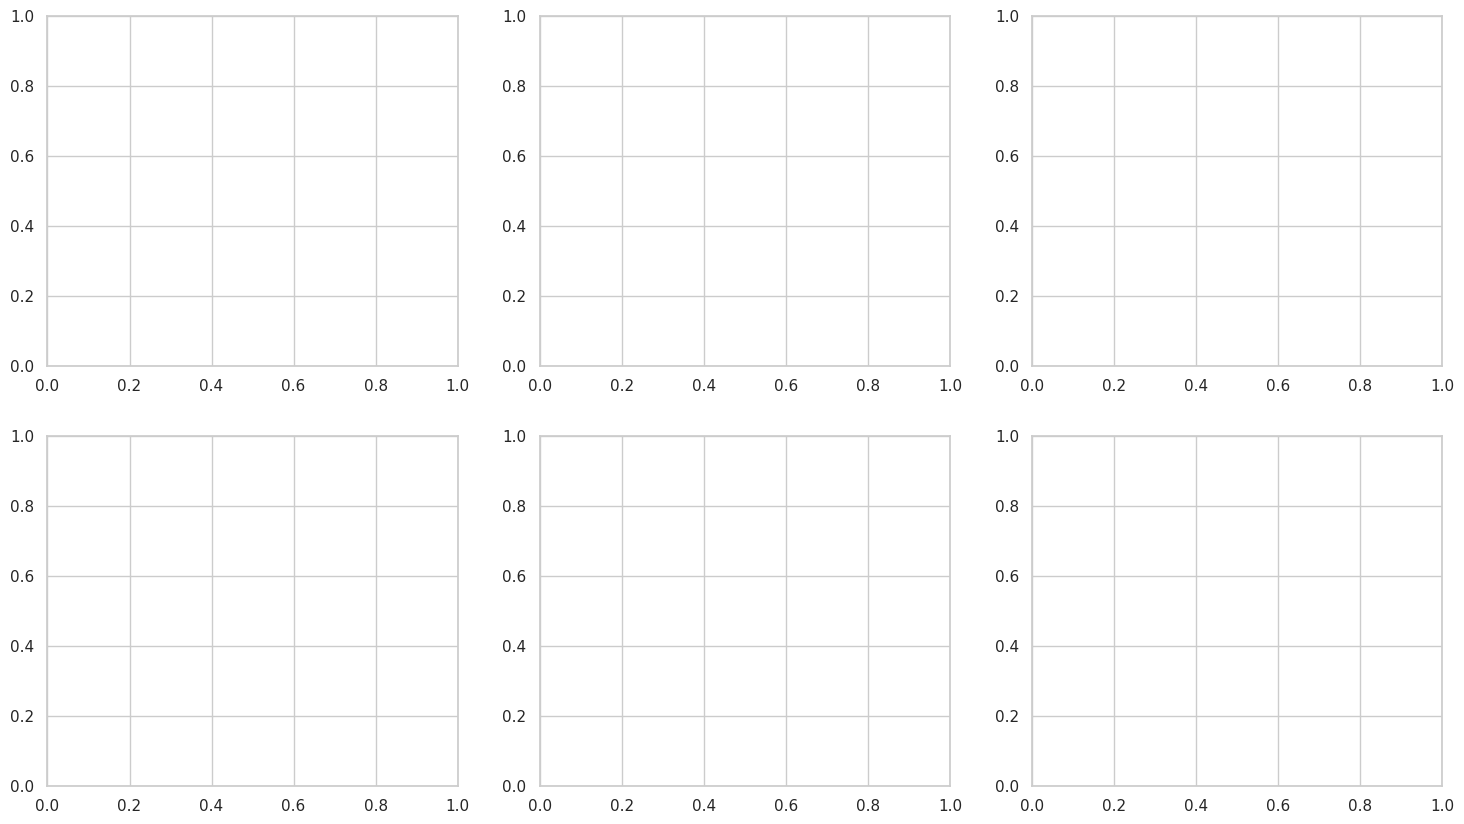

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare a temporary dataframe for categorical analysis on the test set
analyze_df = X_test.copy()
analyze_df['PD'] = 1 - y_prob_pd
analyze_df['EAD'] = y_pred_ead
analyze_df['LGD'] = y_pred_lgd

# Define categories to analyze
cats = ['Education', 'Property_Area']
metrics = ['PD', 'EAD', 'LGD']

fig, axes = plt.subplots(len(cats), len(metrics), figsize=(18, 10))

for i, cat in enumerate(cats):
    for j, metric in enumerate(metrics):
        sns.barplot(data=analyze_df, x=cat, y=metric, ax=axes[i, j], palette='viridis', ci=None)
        axes[i, j].set_title(f'Avg {metric} by {cat}')
        axes[i, j].set_ylabel(metric)

plt.tight_layout()
plt.show()

### 18. Risk Component Summary Table

We will now aggregate the predicted risk metrics (PD, EAD, LGD) by key segments to identify which groups contribute most to the overall expected loss.

In [ ]:
# Re-calculate the analyze_df using original categorical columns for grouping
# We use the index of X_test to pull the original values from 'df'
analyze_df_summary = df.loc[X_test.index, ['Education', 'Property_Area']].copy()
analyze_df_summary['PD'] = 1 - y_prob_pd
analyze_df_summary['EAD'] = y_pred_ead
analyze_df_summary['LGD'] = y_pred_lgd
analyze_df_summary['Expected_Loss'] = analyze_df_summary['PD'] * analyze_df_summary['LGD'] * analyze_df_summary['EAD']

# Create summary table for Education
edu_summary = analyze_df_summary.groupby('Education')[['PD', 'EAD', 'LGD', 'Expected_Loss']].mean().reset_index()

# Create summary table for Property Area
area_summary = analyze_df_summary.groupby('Property_Area')[['PD', 'EAD', 'LGD', 'Expected_Loss']].mean().reset_index()

print("Average Risk Metrics by Education Level:")
display(edu_summary)

print("\nAverage Risk Metrics by Property Area:")
display(area_summary)

Average Risk Metrics by Education Level:


,Education,PD,EAD,LGD,Expected_Loss
0,Graduate,0.314072,142.211429,0.500069,22.803553
1,Not Graduate,0.422468,104.788928,0.475546,22.512868



Average Risk Metrics by Property Area:


,Property_Area,PD,EAD,LGD,Expected_Loss
0,Rural,0.381102,137.003439,0.491361,25.321430
1,Semiurban,0.290118,134.448861,0.500147,19.445812
2,Urban,0.362535,130.786208,0.490487,24.713987


### 19. Final Model Output: Risk Scorecard

This final table consolidates all component models into a single Risk Scorecard. It allows the business to see the predicted probability, the potential exposure, and the final Expected Loss (EL) for every applicant in the test set.

In [ ]:
# Consolidate all predictions into a final scorecard
risk_scorecard = df.loc[X_test.index, ['Loan_ID', 'Gender', 'Married', 'Education', 'ApplicantIncome']].copy()

risk_scorecard['PD_Probability'] = (1 - y_prob_pd).round(4)
risk_scorecard['Predicted_EAD_Amount'] = y_pred_ead.round(2)
risk_scorecard['Predicted_LGD_Rate'] = y_pred_lgd.round(4)
risk_scorecard['Expected_Loss_Value'] = (risk_scorecard['PD_Probability'] * risk_scorecard['Predicted_LGD_Rate'] * risk_scorecard['Predicted_EAD_Amount']).round(2)

# Add a risk rating based on Expected Loss
risk_scorecard['Risk_Segment'] = pd.qcut(risk_scorecard['Expected_Loss_Value'], q=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Sort by Expected Loss to see highest risk first
risk_scorecard = risk_scorecard.sort_values(by='Expected_Loss_Value', ascending=False)

print("Final Credit Risk Scorecard (Top 10 High-Risk Applications):")
display(risk_scorecard.head(10))

# Summary of segments
print("\nSummary of Risk Segments:")
display(risk_scorecard.groupby('Risk_Segment')['Expected_Loss_Value'].agg(['count', 'mean', 'sum']))

Final Credit Risk Scorecard (Top 10 High-Risk Applications):


,Loan_ID,Gender,Married,Education,ApplicantIncome,PD_Probability,Predicted_EAD_Amount,Predicted_LGD_Rate,Expected_Loss_Value,Risk_Segment
54,LP001186,Female,Yes,Graduate,10171.25,0.9070,232.35,0.5499,115.89,High Risk
177,LP001610,Male,Yes,Graduate,5516.00,0.7590,238.45,0.5603,101.41,High Risk
108,LP001379,Male,Yes,Graduate,3800.00,0.8046,206.77,0.5306,88.27,High Risk
180,LP001633,Male,Yes,Graduate,6400.00,0.9002,197.13,0.4966,88.12,High Risk
293,LP001945,Female,No,Graduate,5417.00,0.9022,150.23,0.5791,78.49,High Risk
201,LP001677,Male,No,Graduate,4923.00,0.7850,178.12,0.5535,77.39,High Risk
280,LP001910,Male,No,Not Graduate,4053.00,0.9693,155.64,0.5050,76.19,High Risk
326,LP002068,Male,No,Graduate,4917.00,0.9180,139.11,0.5711,72.93,High Risk
414,LP002335,Female,Yes,Not Graduate,2149.00,0.8379,176.22,0.4876,72.00,High Risk
346,LP002130,Male,Yes,Not Graduate,3523.00,0.9243,149.98,0.5094,70.62,High Risk



Summary of Risk Segments:


/tmp/ipykernel_9497/9073695.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(risk_scorecard.groupby('Risk_Segment')['Expected_Loss_Value'].agg(['count', 'mean', 'sum']))


,count,mean,sum
Risk_Segment,,,
Low Risk,62,6.961129,431.59
Medium Risk,61,15.723607,959.14
High Risk,62,45.420161,2816.05


### 20. Exporting Results

We will now save the final risk scorecard to a CSV file for reporting or further analysis.

In [ ]:
# Save the scorecard to CSV
risk_scorecard.to_csv('credit_risk_scorecard.csv', index=False)

print("Scorecard successfully saved as 'credit_risk_scorecard.csv'")

# Optional: Download the file directly in Colab
from google.colab import files
files.download('credit_risk_scorecard.csv')

Scorecard successfully saved as 'credit_risk_scorecard.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 21. Risk Level Visualization per Main Features

We will now visualize how the final 'Expected Loss' is distributed across key categories to understand the main drivers of financial risk in the portfolio.

/tmp/ipykernel_9497/4076766071.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_viz_df, x=feature, y='Expected_Loss', palette='Reds', errorbar=None)
/tmp/ipykernel_9497/4076766071.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_viz_df, x=feature, y='Expected_Loss', palette='Reds', errorbar=None)
/tmp/ipykernel_9497/4076766071.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_viz_df, x=feature, y='Expected_Loss', palette='Reds', errorbar=None)


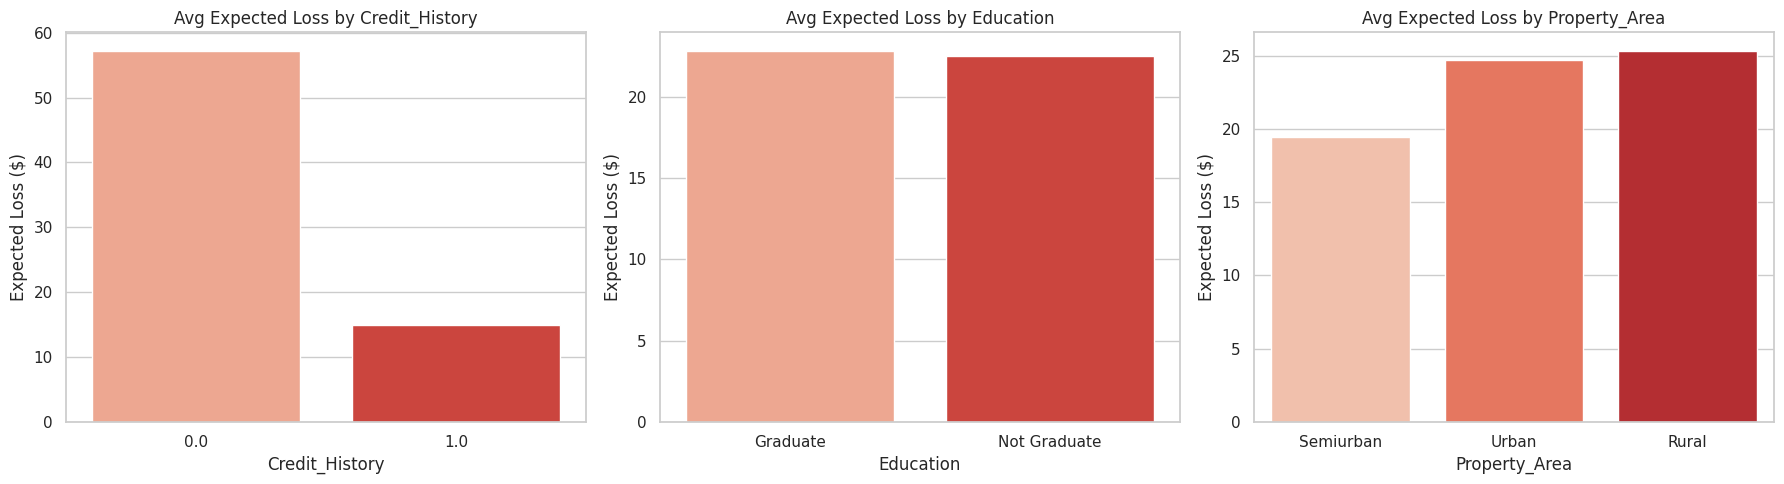

In [ ]:
# Map original categorical values back to the test set for visualization
risk_viz_df = df.loc[X_test.index].copy()
risk_viz_df['Expected_Loss'] = risk_scorecard['Expected_Loss_Value']

# Define key features to visualize
key_features = ['Credit_History', 'Education', 'Property_Area']

plt.figure(figsize=(18, 5))

for i, feature in enumerate(key_features, 1):
    plt.subplot(1, 3, i)
    sns.barplot(data=risk_viz_df, x=feature, y='Expected_Loss', palette='Reds', errorbar=None)
    plt.title(f'Avg Expected Loss by {feature}')
    plt.ylabel('Expected Loss ($)')

plt.tight_layout()
plt.show()

### 22. Updated CSV Export

We are exporting the final risk scorecard, which now includes the categorized risk segments and Expected Loss values.

In [ ]:
# Re-exporting the finalized scorecard to CSV
final_csv_path = 'final_credit_risk_scorecard.csv'
risk_scorecard.to_csv(final_csv_path, index=False)

print(f"Updated scorecard saved as '{final_csv_path}'")

# Download the updated file
from google.colab import files
files.download(final_csv_path)

Updated scorecard saved as 'final_credit_risk_scorecard.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 23. Synthesized Traceable Export

We will now create a version of the scorecard that includes a 'Formula_Trace' column. This provides transparency by showing the raw inputs ($PD$, $LGD$, and $EAD$) used to calculate the final Expected Loss for each applicant.

In [ ]:
# Final Traceable Model Export
synthesized_df = risk_scorecard.copy()

# Include calculation trace for transparency
synthesized_df['Calculation_Formula'] = synthesized_df.apply(
    lambda x: f"PD({x['PD_Probability']}) * LGD({x['Predicted_LGD_Rate']}) * EAD(${x['Predicted_EAD_Amount']})",
    axis=1
)

# Consolidate all relevant risk features and predictions
final_export_cols = [
    'Loan_ID', 'Risk_Segment', 'Expected_Loss_Value', 'Calculation_Formula',
    'PD_Probability', 'Predicted_EAD_Amount', 'Predicted_LGD_Rate',
    'ApplicantIncome', 'Education', 'Married'
]

synthesized_df = synthesized_df[final_export_cols]

# Save and download
traceable_csv_path = 'comprehensive_traceable_risk_model.csv'
synthesized_df.to_csv(traceable_csv_path, index=False)

print(f"Comprehensive traceable model results saved to {traceable_csv_path}")
display(synthesized_df.head())

from google.colab import files
files.download(traceable_csv_path)

Comprehensive traceable model results saved to comprehensive_traceable_risk_model.csv


,Loan_ID,Risk_Segment,Expected_Loss_Value,Calculation_Formula,PD_Probability,Predicted_EAD_Amount,Predicted_LGD_Rate,ApplicantIncome,Education,Married
54,LP001186,High Risk,115.89,PD(0.907) * LGD(0.5499) * EAD($232.35),0.9070,232.35,0.5499,10171.25,Graduate,Yes
177,LP001610,High Risk,101.41,PD(0.759) * LGD(0.5603) * EAD($238.45),0.7590,238.45,0.5603,5516.00,Graduate,Yes
108,LP001379,High Risk,88.27,PD(0.8046) * LGD(0.5306) * EAD($206.77),0.8046,206.77,0.5306,3800.00,Graduate,Yes
180,LP001633,High Risk,88.12,PD(0.9002) * LGD(0.4966) * EAD($197.13),0.9002,197.13,0.4966,6400.00,Graduate,Yes
293,LP001945,High Risk,78.49,PD(0.9022) * LGD(0.5791) * EAD($150.23),0.9022,150.23,0.5791,5417.00,Graduate,No


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 24. Export to GitHub

To use this cell:
1. Create a **Personal Access Token (fine-grained or classic)** on GitHub with 'contents' write access.
2. Add it to Colab's 'Secrets' (🔑 icon on the left) with the name `GITHUB_TOKEN`.
3. Fill in your `GITHUB_USER` and `GITHUB_REPO` below.

In [65]:
import requests
import base64
import json
from google.colab import userdata, _message

# --- 1. CONFIGURATION ---
# Replace with your actual GitHub details
GITHUB_USER = 'your-username'
GITHUB_REPO = 'credit-risk-models'
GITHUB_BRANCH = 'main'
FILENAME_IN_REPO = 'LGD_PD_EAD.ipynb'

# --- 2. GET CURRENT NOTEBOOK CONTENT ---
try:
    # This fetches the current notebook state
    notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=5)
    content_bytes = json.dumps(notebook_json['ipynb'], indent=2).encode('utf-8')
    encoded_content = base64.b64encode(content_bytes).decode('utf-8')

    # --- 3. GITHUB API CALL ---
    token = userdata.get('GITHUB_TOKEN')
    url = f'https://api.github.com/repos/{GITHUB_USER}/{GITHUB_REPO}/contents/{FILENAME_IN_REPO}'
    headers = {
        'Authorization': f'token {token}',
        'Accept': 'application/vnd.github.v3+json'
    }

    # Check if file exists to get the 'sha' (required for updates)
    resp = requests.get(url, headers=headers)
    sha = resp.json().get('sha') if resp.status_code == 200 else None

    data = {
        'message': 'Update Credit Risk Analysis notebook',
        'content': encoded_content,
        'branch': GITHUB_BRANCH
    }
    if sha:
        data['sha'] = sha

    # Execute upload
    put_resp = requests.put(url, headers=headers, json=data)

    if put_resp.status_code in [200, 201]:
        print(f'✅ Success! Notebook uploaded to: {put_resp.json().get("commit").get("html_url")}')
    else:
        print(f'❌ Failed: {put_resp.status_code}')
        print(put_resp.json())

except Exception as e:
    print(f'An error occurred: {e}')

FileNotFoundError: [Errno 2] No such file or directory: '/content/LGD,PD,EAD.ipynb'

### Final Step: Push Notebook to GitHub

Ensure you have added your `GITHUB_TOKEN` to the Colab Secrets (🔑 icon) and enabled access for this notebook.

In [69]:
import requests
import base64
import json
from google.colab import userdata

# --- 1. CONFIGURATION ---
# Change these to your actual GitHub details
GITHUB_USER = 'your-username'
GITHUB_REPO = 'your-repo-name'
GITHUB_BRANCH = 'main'
# This will be the name of the file in your repository
FILENAME_IN_REPO = 'Credit_Risk_Analysis.ipynb'

# --- 2. PREPARE THE NOTEBOOK CONTENT ---
# Using a longer timeout (20s) to ensure the request doesn't return None
from google.colab import _message
notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=20)

if notebook_json is None:
    print('❌ Error: Could not retrieve notebook data. Try saving the notebook (Ctrl+S) and running this cell again.')
else:
    content_bytes = json.dumps(notebook_json['ipynb'], indent=2).encode('utf-8')
    encoded_content = base64.b64encode(content_bytes).decode('utf-8')

    # --- 3. GITHUB API CALL ---
    token = userdata.get('GITHUB_TOKEN')
    url = f'https://api.github.com/repos/{GITHUB_USER}/{GITHUB_REPO}/contents/{FILENAME_IN_REPO}'
    headers = {
        'Authorization': f'token {token}',
        'Accept': 'application/vnd.github.v3+json'
    }

    # Check if the file exists to get the 'sha' (required for updates)
    resp = requests.get(url, headers=headers)
    sha = resp.json().get('sha') if resp.status_code == 200 else None

    data = {
        'message': 'Upload credit risk model notebook from Colab',
        'content': encoded_content,
        'branch': GITHUB_BRANCH
    }
    if sha:
        data['sha'] = sha

    # Execute upload
    put_resp = requests.put(url, headers=headers, json=data)

    if put_resp.status_code in [200, 201]:
        print(f'✅ Success! Notebook uploaded to: {put_resp.json().get("commit").get("html_url")}')
    else:
        print(f'❌ Failed: {put_resp.status_code}')
        print(put_resp.json())

❌ Failed: 404
{'message': 'Not Found', 'documentation_url': 'https://docs.github.com/rest/repos/contents#create-or-update-file-contents', 'status': '404'}


In [70]:
import requests
from google.colab import userdata

# --- 1. SET YOUR CONFIG ---
GITHUB_USER = 'your-username'
GITHUB_REPO = 'your-repo-name'

# --- 2. VERIFY REPO ---
token = userdata.get('GITHUB_TOKEN')
url = f'https://api.github.com/repos/{GITHUB_USER}/{GITHUB_REPO}'
headers = {'Authorization': f'token {token}'}

resp = requests.get(url, headers=headers)

if resp.status_code == 200:
    repo_data = resp.json()
    print(f"✅ Success! Repository found.")
    print(f"   Full Name: {repo_data['full_name']}")
    print(f"   Private: {repo_data['private']}")
    print(f"   Permissions (push): {repo_data.get('permissions', {}).get('push', False)}")
elif resp.status_code == 404:
    print(f"❌ Repository NOT FOUND. Please check that '{GITHUB_USER}/{GITHUB_REPO}' is correct and the repository exists.")
else:
    print(f"❌ Error {resp.status_code}: {resp.json().get('message')}")

❌ Repository NOT FOUND. Please check that 'your-username/your-repo-name' is correct and the repository exists.


### 1. GitHub Configuration
Fill in your details here. Make sure you have a `GITHUB_TOKEN` saved in the Colab Secrets (🔑).

In [72]:
#@title GitHub details
GITHUB_USER = "drwilliamwilliam-c" #@param {type:"string"}
GITHUB_REPO = "credit_risk_modelling" #@param {type:"string"}
GITHUB_BRANCH = "main" #@param {type:"string"}
FILENAME_IN_REPO = "Credit_Risk_Analysis.ipynb" #@param {type:"string"}

### 2. Export to GitHub
Run this cell to upload the current notebook.

In [73]:
import requests
import base64
import json
from google.colab import userdata, _message

try:
    # 1. Fetch current notebook data
    notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=20)
    if notebook_json is None:
        raise ValueError("Could not capture notebook content. Please save (Ctrl+S) and try again.")

    content_bytes = json.dumps(notebook_json['ipynb'], indent=2).encode('utf-8')
    encoded_content = base64.b64encode(content_bytes).decode('utf-8')

    # 2. Setup GitHub API
    token = userdata.get('GITHUB_TOKEN')
    url = f'https://api.github.com/repos/{GITHUB_USER}/{GITHUB_REPO}/contents/{FILENAME_IN_REPO}'
    headers = {
        'Authorization': f'token {token}',
        'Accept': 'application/vnd.github.v3+json'
    }

    # 3. Check for existing file SHA (for updates)
    resp = requests.get(url, headers=headers)
    sha = resp.json().get('sha') if resp.status_code == 200 else None

    # 4. Push to GitHub
    data = {
        'message': 'Upload credit risk model from Colab',
        'content': encoded_content,
        'branch': GITHUB_BRANCH
    }
    if sha:
        data['sha'] = sha

    put_resp = requests.put(url, headers=headers, json=data)

    if put_resp.status_code in [200, 201]:
        print(f'✅ Success! Notebook uploaded to: {put_resp.json().get("commit").get("html_url")}')
    else:
        print(f'❌ Failed ({put_resp.status_code}): {put_resp.json().get("message")}')
        if put_resp.status_code == 404:
            print("Tip: Check if GITHUB_USER and GITHUB_REPO are correct and that your token has 'repo' permissions.")

except Exception as e:
    print(f'❌ Error: {e}')

❌ Failed (404): Not Found
Tip: Check if GITHUB_USER and GITHUB_REPO are correct and that your token has 'repo' permissions.


In [60]:
from google.colab import userdata
try:
    token = userdata.get('GITHUB_TOKEN')
    print('✅ GITHUB_TOKEN is correctly set in Secrets.')
except userdata.SecretNotFoundError:
    print('❌ GITHUB_TOKEN not found. Please click the key icon (🔑) on the left and add a secret named GITHUB_TOKEN.')
except userdata.NotebookAccessError:
    print('⚠️ GITHUB_TOKEN exists but this notebook does not have access. Please toggle the access switch in the Secrets panel.')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

✅ GITHUB_TOKEN is correctly set in Secrets.


#### Interaction Summary:
1.  **High PD + High EAD**: These are the most critical risks. Even if recovery (LGD) is decent, the sheer size of the loan and high default probability lead to high EL.
2.  **Low PD + High EAD**: These are high-exposure but low-probability. Banks often manage these through collateral requirements to lower LGD.
3.  **High PD + Low EAD**: These are frequent but small losses, often managed through automated screening and higher interest rates.